In [8]:
import re
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
import ipdb
from ipywidgets import IntProgress
from IPython.display import display
from math import floor
from datetime import datetime
# --- Configuration ---
SERIAL_PORT = "COM10"  # Replace with your serial port (e.g., "/dev/ttyUSB0" on Linux)
BAUD_RATE = 115200    # Adjust to match your device's baud rate
OUTPUT_FILE = "serial_output.txt"  # File to save the serial stream

# --- Extract histograms from text ---
def extract_histograms(text):
    pattern = r"B (\d+)\s*(.*?)\s*E \d+"
    histograms = []

    for match in re.finditer(pattern, text, re.DOTALL):
        pixel = int(match.group(1))
        histogram_lines = match.group(2).strip().split("\n")

        histogram = []
        for line in histogram_lines:
            values = list(map(int, line.strip().split("_")))
            histogram.extend(values)

        histograms.append(np.array(histogram))

    return histograms

def stream_serial_to_file(port, baud_rate, output_file, pixels, timeout=10):
    """
    Stream serial data to a file and stop if "DONE" is encountered or timeout expires.

    Args:
        port (str): Serial port (e.g., "COM3" or "/dev/ttyUSB0").
        baud_rate (int): Baud rate (e.g., 115200).
        output_file (str): Path to the output file.
        timeout (int): Maximum time (seconds) to wait for data before stopping.

    Returns:
        bool: True if "DONE" was encountered, False if timeout expired.
    """


    max_count = 1000

    bar = IntProgress(min=0, max=max_count) # instantiate the bar
    display(bar) # display the bar


    
    first = True
    begin_numbers = False
    try:
        with serial.Serial(port, baud_rate, timeout=timeout) as ser, \
             open(output_file, "w") as f:
            print(f"Streaming serial data from {port} to {output_file}...")
            start_time = time.time()

            while True:
                if ser.in_waiting:
                    if(first == True):
                        print("beginning of stream");
                        print("\n\r");
                        first = False
                    line = ser.readline().decode("utf-8", errors="ignore").strip()
                    if line:  # Skip empty lines
                        if(line.startswith("B 0")):
                            begin_numbers = True
                            t_begin = time.time()
                            #ipdb.set_trace()
                            
                        if(begin_numbers==False):
                            print(line)
                        else:
                            if line.startswith("B "):
                                pixel_num = line.split(" ")[1]
                                progress = floor(int(pixel_num)/pixels*max_count)
                                bar.value = progress
                                if line == "B 100":
                                    t_100 = time.time()
                                    dt_100 = t_100 - t_begin
                                    dt_end = dt_100 * pixels/100
                                    t_end = t_begin + dt_end
                                    formatted_end_time = datetime.fromtimestamp(t_end).strftime('%H:%M:%S')
                                    formatted_total_time = datetime.fromtimestamp(dt_end).strftime('%H:%M:%S')

                                    #hours = t_total / 3600
                                    #minutes = (t_total - hours*3600) /60
                                    #seconds = t_total - hours * 3600 - minutes * 60
                                    #ipdb.set_trace()
                                    #current_time = end_time.strftime("%H:%M:%S")
                                    print("Receiving this image should take: " + formatted_total_time + "\r\n")
                                    print(f"it should be done at: "  + formatted_end_time + "\r\n")
                                
                            f.write(line + "\n")
                            f.flush()  # Ensure data is written immediately
                            #print(line)  # Optional: Print to console for debugging

                            # Check for "DONE" (case-insensitive)
                            if "DONE" in line:
                                print("Found 'DONE' in serial output. Stopping stream.")
                                return True

                # Exit after timeout (seconds) if no data is received
                if timeout and (time.time() - start_time) > timeout:
                    print("Timeout reached. Stopping serial stream.")
                    return False

    except serial.SerialException as e:
        print(f"Serial error: {e}")
        return False
    except KeyboardInterrupt:
        print("Stopped by user.")
        return False




def plot_histograms_as_image(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the maximum bin in its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint8)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width

        # Find the index of the maximum bin value
        max_bin_index = np.argmax(histogram)

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(normalized_brightness)
        image[row, col] = normalized_brightness

    # Plot the image
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
    plt.colorbar(label="Brightness (Max Bin Index)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image    

In [9]:
# --- Main workflow ---
frame_width = 512
# Step 1: Stream serial data to file
stream_serial_to_file(SERIAL_PORT, BAUD_RATE, OUTPUT_FILE, frame_width*frame_width, timeout=3000000000000)

IntProgress(value=0, max=1000)

Streaming serial data from COM10 to serial_output.txt...
beginning of stream


------------------------------------------------------------
----------- GPX2_LVDS_READOUT -----------
------------------------------------------------------------
System ready.
Current Settings are expecting a reference clock frequency of 10000 kHz.
Currently listening for STOP signals on channel 1.
the expected laser clock period is: 100000 ps.
the specified bin width is: 4096 ps.
the histogram will be 36 bins wide.
Successfully wrote 65536 words to BRAM
Receiving this image should take: 01:35:11

it should be done at: 01:31:35

Found 'DONE' in serial output. Stopping stream.


True

In [10]:
# Step 2: Read the file and extract histograms
with open(OUTPUT_FILE, "r") as f:
    serial_output = f.read()

histograms = extract_histograms(serial_output)

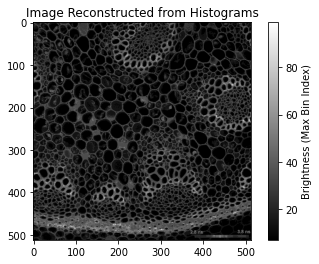

In [11]:
image = plot_histograms_as_image(histograms,frame_width)